ML - CASE STUDY - CLASSIFICATION ALGORITHMS 

# 23CSE301 Machine Learning Capstone Project
## Classification Track – Part A

### Dataset
Mobile Phone Price Classification Dataset

### Objective
Predict the mobile phone price range using five classification algorithms.

### Algorithms
1. Logistic Regression
2. K-Nearest Neighbors
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Classifier

### Evaluation Metrics
- Accuracy
- Weighted Precision
- Weighted Recall
- Weighted F1-Score
- One-vs-Rest ROC-AUC
- Confusion Matrix

Random State = 42

In [63]:
# IMPORT LIBRARIES
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, auc

RANDOM_STATE = 42
TARGET = "price_range"
sns.set_theme(style="whitegrid")

# LOAD DATASET
df = pd.read_csv("train.csv")

print("DATASET SHAPE:", df.shape)

print("\nDATA TYPES")
display(df.dtypes.to_frame("Data Type"))

print("\nMISSING VALUES")
display(df.isnull().sum().to_frame("Missing Values"))

print("\nDUPLICATES:", df.duplicated().sum())

print("\nTARGET DISTRIBUTION")
display(df[TARGET].value_counts().sort_index().to_frame("Count"))

print("\nSTATISTICAL SUMMARY")
display(df.describe().T)

# BASIC CLEANING
features = [c for c in df.select_dtypes(include=np.number).columns if c != TARGET]
for c in features:
    if df[c].isnull().sum() > 0:
        df[c] = df[c].fillna(df[c].median())
df = df.drop_duplicates().reset_index(drop=True)

# OUTLIER CHECK
Q1 = df[features].quantile(.25)
Q3 = df[features].quantile(.75)
IQR = Q3 - Q1
outliers = ((df[features] < Q1 - 1.5 * IQR) | (df[features] > Q3 + 1.5 * IQR)).sum()

print("\nOUTLIER CHECK")
display(outliers.to_frame("Outlier Count"))

DATASET SHAPE: (2000, 21)

DATA TYPES


,Data Type
battery_power,int64
blue,int64
clock_speed,float64
dual_sim,int64
fc,int64
four_g,int64
int_memory,int64
m_dep,float64
mobile_wt,int64
n_cores,int64



MISSING VALUES


,Missing Values
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0



DUPLICATES: 0

TARGET DISTRIBUTION


,Count
price_range,
0,500
1,500
2,500
3,500



STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
battery_power,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
clock_speed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
dual_sim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
fc,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
four_g,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
int_memory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
m_dep,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
mobile_wt,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
n_cores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0



OUTLIER CHECK


,Outlier Count
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,18
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


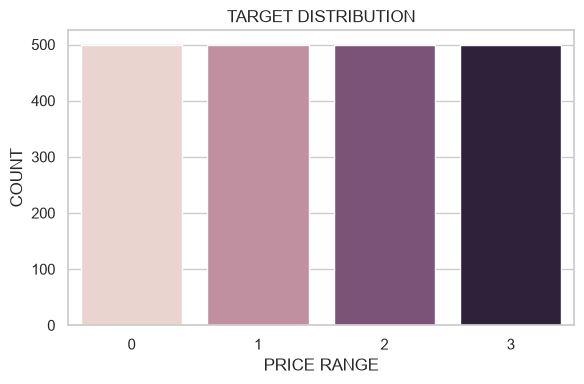

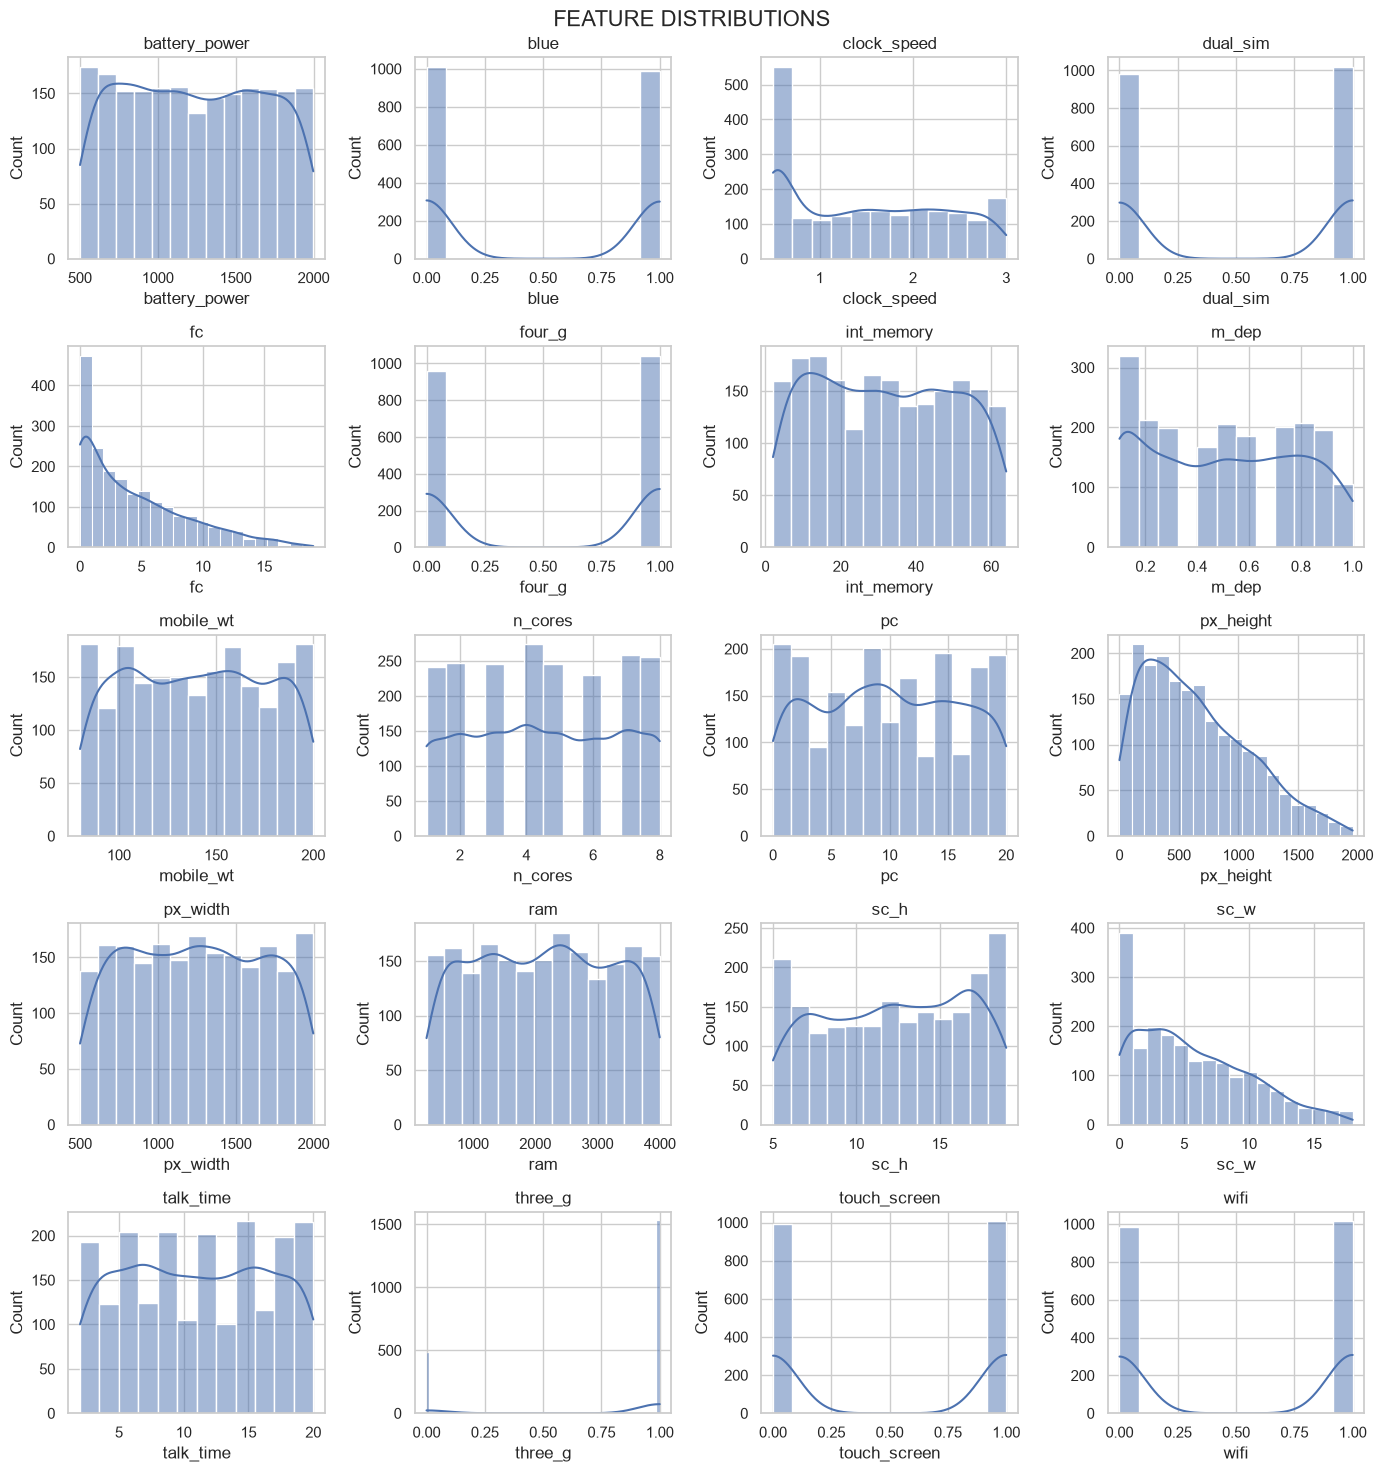

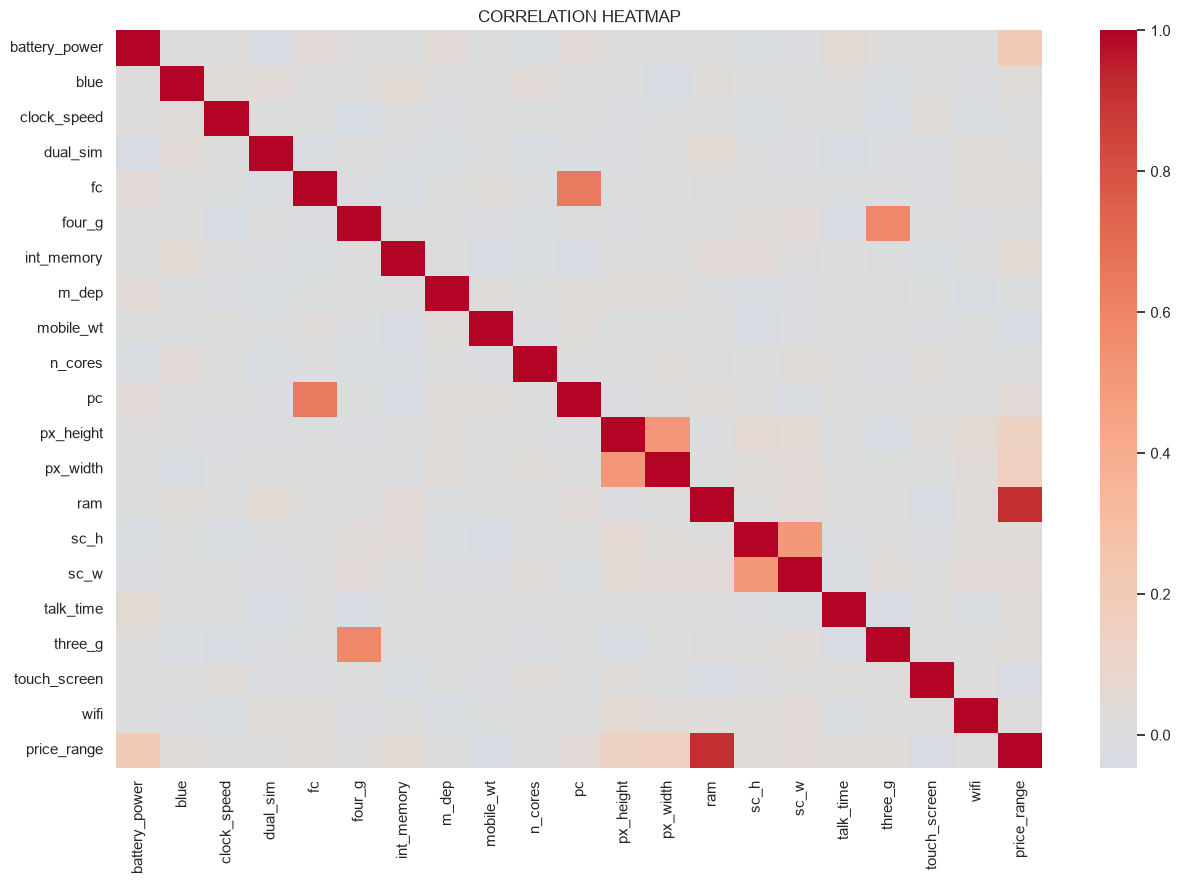

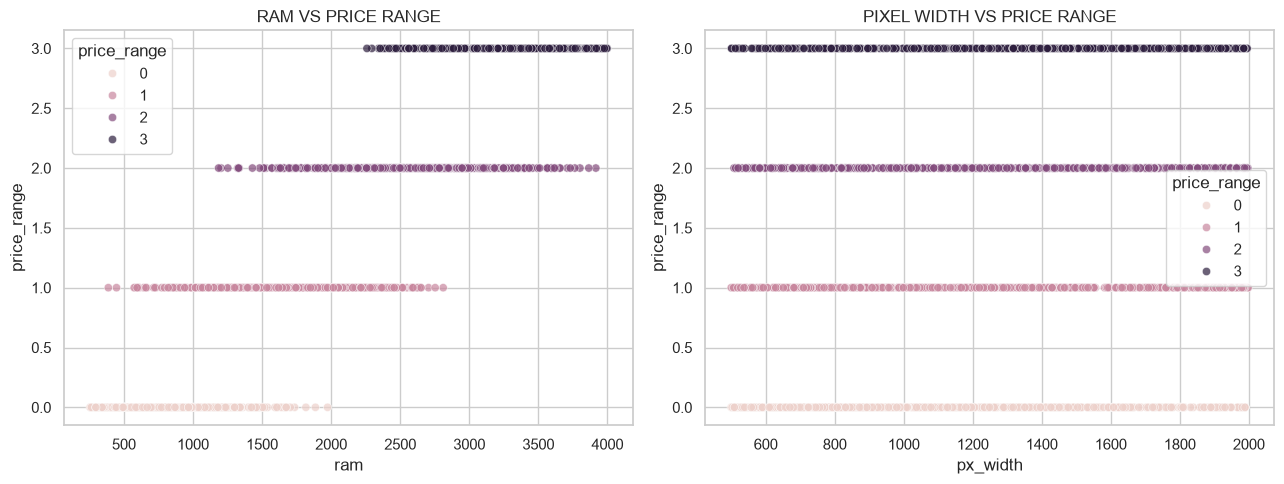

In [64]:
# TARGET DISTRIBUTION
plt.figure(figsize=(6,4))
sns.countplot(data=df, x=TARGET, hue=TARGET, legend=False)
plt.title("TARGET DISTRIBUTION")
plt.xlabel("PRICE RANGE")
plt.ylabel("COUNT")
plt.tight_layout()
plt.show()

# FEATURE DISTRIBUTIONS
fig, axes = plt.subplots(5, 4, figsize=(14, 15))
axes = axes.ravel()
for ax, col in zip(axes, features):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(col)
plt.suptitle("FEATURE DISTRIBUTIONS", fontsize=16)
plt.tight_layout()
plt.show()

# CORRELATION HEATMAP
plt.figure(figsize=(13,9))
sns.heatmap(df[features + [TARGET]].corr(), cmap="coolwarm", center=0)
plt.title("CORRELATION HEATMAP")
plt.tight_layout()
plt.show()

# FEATURE RELATIONSHIPS
fig, axes = plt.subplots(1, 2, figsize=(13,5))
sns.scatterplot(data=df, x="ram", y=TARGET, hue=TARGET, alpha=.7, ax=axes[0])
axes[0].set_title("RAM VS PRICE RANGE")
sns.scatterplot(data=df, x="px_width", y=TARGET, hue=TARGET, alpha=.7, ax=axes[1])
axes[1].set_title("PIXEL WIDTH VS PRICE RANGE")
plt.tight_layout()
plt.show()

In [65]:
# FEATURES AND TARGET
X = df.drop(columns=[TARGET])
y = df[TARGET]

# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.20, stratify=y, random_state=RANDOM_STATE)
print("TRAIN TEST SPLIT")
display(pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "Samples": [len(X_train), len(X_test)],
    "Features": [X_train.shape[1], X_test.shape[1]]
}))

# FEATURE ENGINEERING
def engineer(data):
    data = data.copy()
    data["screen_area"] = data["sc_h"] * data["sc_w"]
    data["pixel_area"] = data["px_height"] * data["px_width"]
    data["total_camera"] = data["fc"] + data["pc"]
    data["connectivity_count"] = data["blue"] + data["dual_sim"] + data["four_g"] + data["three_g"] + data["touch_screen"] + data["wifi"]
    return data
X_train = engineer(X_train)
X_test = engineer(X_test)

# OUTLIER TREATMENT
continuous = ["battery_power", "clock_speed", "fc", "int_memory", "m_dep", "mobile_wt", "n_cores", "pc", "px_height", "px_width", "ram", "sc_h", "sc_w", "talk_time", "screen_area", "pixel_area", "total_camera"]
Q1 = X_train[continuous].quantile(.25)
Q3 = X_train[continuous].quantile(.75)
IQR = Q3 - Q1
X_train[continuous] = X_train[continuous].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR, axis=1)
X_test[continuous] = X_test[continuous].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR, axis=1)

# MODEL DATA
X_train_lr, X_test_lr = X_train.copy(), X_test.copy()
X_train_knn, X_test_knn = X_train.copy(), X_test.copy()
X_train_nb, X_test_nb = X_train.copy(), X_test.copy()
X_train_dt, X_test_dt = X_train.copy(), X_test.copy()
X_train_svc, X_test_svc = X_train.copy(), X_test.copy()
print("FEATURES AFTER ENGINEERING:", X_train.shape[1])

TRAIN TEST SPLIT


,Dataset,Samples,Features
0,Training,1600,20
1,Testing,400,20


FEATURES AFTER ENGINEERING: 24


In [66]:
# LOGISTIC REGRESSION

lr_model = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=3000, random_state=RANDOM_STATE))])
lr_model.fit(X_train_lr, y_train)

lr_pred = lr_model.predict(X_test_lr)
lr_proba = lr_model.predict_proba(X_test_lr)

print("LOGISTIC REGRESSION")
display(pd.DataFrame(classification_report(y_test, lr_pred, output_dict=True)).T.round(4))

LOGISTIC REGRESSION


,precision,recall,f1-score,support
0,0.9899,0.9800,0.9849,100.0000
1,0.9600,0.9600,0.9600,100.0000
2,0.9583,0.9200,0.9388,100.0000
3,0.9429,0.9900,0.9659,100.0000
accuracy,0.9625,0.9625,0.9625,0.9625
macro avg,0.9628,0.9625,0.9624,400.0000
weighted avg,0.9628,0.9625,0.9624,400.0000


In [67]:
# K NEAREST NEIGHBORS

knn_model = Pipeline([("scaler", StandardScaler()), ("model", KNeighborsClassifier(n_neighbors=5))])
knn_model.fit(X_train_knn, y_train)

knn_pred = knn_model.predict(X_test_knn)
knn_proba = knn_model.predict_proba(X_test_knn)

print("K NEAREST NEIGHBORS")
display(pd.DataFrame(classification_report(y_test, knn_pred, output_dict=True)).T.round(4))

K NEAREST NEIGHBORS


,precision,recall,f1-score,support
0,0.6019,0.62,0.6108,100.00
1,0.3504,0.41,0.3779,100.00
2,0.3267,0.33,0.3284,100.00
3,0.6582,0.52,0.5810,100.00
accuracy,0.4700,0.47,0.4700,0.47
macro avg,0.4843,0.47,0.4745,400.00
weighted avg,0.4843,0.47,0.4745,400.00


In [68]:
# GAUSSIAN NAIVE BAYES

nb_model = Pipeline([("scaler", StandardScaler()), ("model", GaussianNB())])
nb_model.fit(X_train_nb, y_train)

nb_pred = nb_model.predict(X_test_nb)
nb_proba = nb_model.predict_proba(X_test_nb)

print("GAUSSIAN NAIVE BAYES")
display(pd.DataFrame(classification_report(y_test, nb_pred, output_dict=True)).T.round(4))

GAUSSIAN NAIVE BAYES


,precision,recall,f1-score,support
0,0.9394,0.93,0.9347,100.00
1,0.7245,0.71,0.7172,100.00
2,0.7030,0.71,0.7065,100.00
3,0.9118,0.93,0.9208,100.00
accuracy,0.8200,0.82,0.8200,0.82
macro avg,0.8197,0.82,0.8198,400.00
weighted avg,0.8197,0.82,0.8198,400.00


In [69]:
# DECISION TREE

dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE)
dt_model.fit(X_train_dt, y_train)

dt_pred = dt_model.predict(X_test_dt)
dt_proba = dt_model.predict_proba(X_test_dt)

print("DECISION TREE")
display(pd.DataFrame(classification_report(y_test, dt_pred, output_dict=True)).T.round(4))

DECISION TREE


,precision,recall,f1-score,support
0,0.9412,0.9600,0.9505,100.0000
1,0.8316,0.7900,0.8103,100.0000
2,0.7333,0.7700,0.7512,100.0000
3,0.8878,0.8700,0.8788,100.0000
accuracy,0.8475,0.8475,0.8475,0.8475
macro avg,0.8485,0.8475,0.8477,400.0000
weighted avg,0.8485,0.8475,0.8477,400.0000


In [70]:
# SUPPORT VECTOR MACHINE

svc_model = Pipeline([("scaler", StandardScaler()), ("model", SVC(C=1.0, kernel="rbf", probability=True, random_state=RANDOM_STATE))])
svc_model.fit(X_train_svc, y_train)

svc_pred = svc_model.predict(X_test_svc)
svc_proba = svc_model.predict_proba(X_test_svc)

print("SUPPORT VECTOR MACHINE")
display(pd.DataFrame(classification_report(y_test, svc_pred, output_dict=True)).T.round(4))

SUPPORT VECTOR MACHINE


,precision,recall,f1-score,support
0,0.9400,0.9400,0.9400,100.0000
1,0.8617,0.8100,0.8351,100.0000
2,0.7706,0.8400,0.8038,100.0000
3,0.9072,0.8800,0.8934,100.0000
accuracy,0.8675,0.8675,0.8675,0.8675
macro avg,0.8699,0.8675,0.8681,400.0000
weighted avg,0.8699,0.8675,0.8681,400.0000


MODEL PERFORMANCE


,Algorithm,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9625,0.9628,0.9625,0.9624,0.9986
1,KNN,0.4700,0.4843,0.4700,0.4745,0.7298
2,Gaussian NB,0.8200,0.8197,0.8200,0.8198,0.9531
3,Decision Tree,0.8475,0.8485,0.8475,0.8477,0.8983
4,SVM,0.8675,0.8699,0.8675,0.8681,0.9797


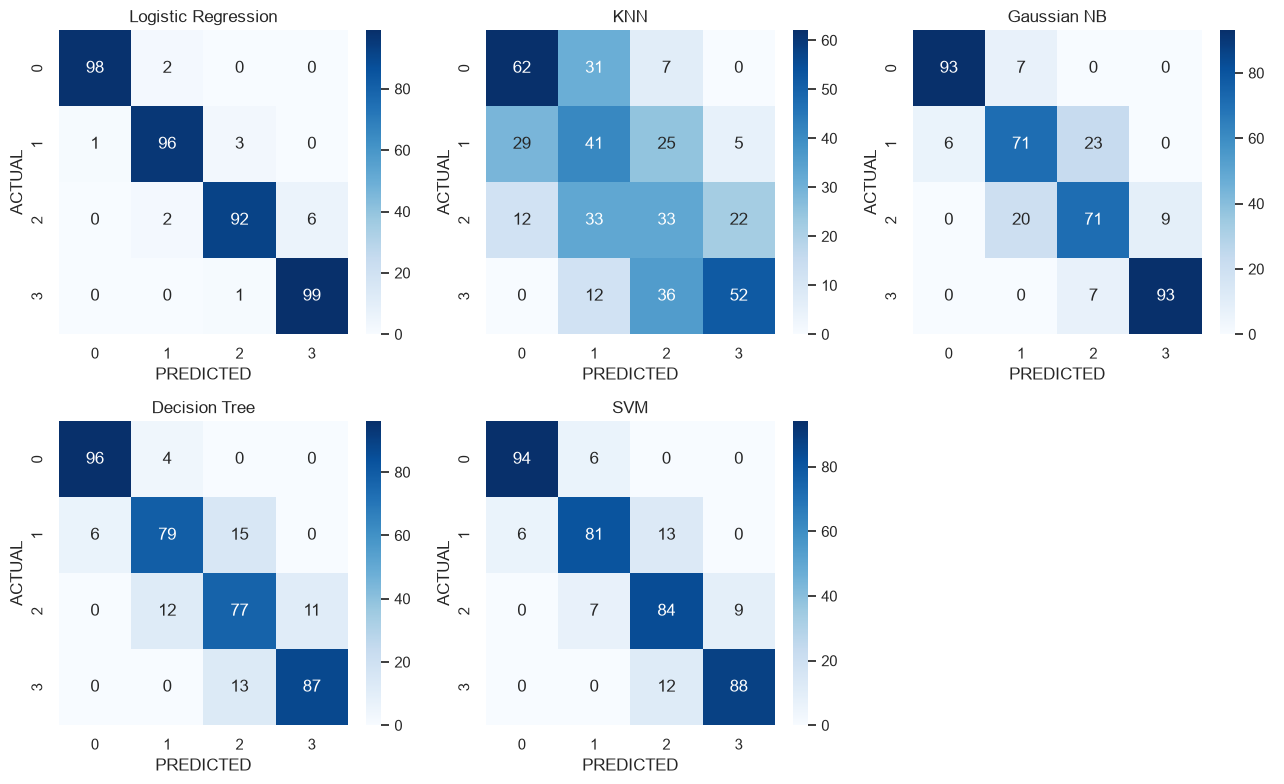

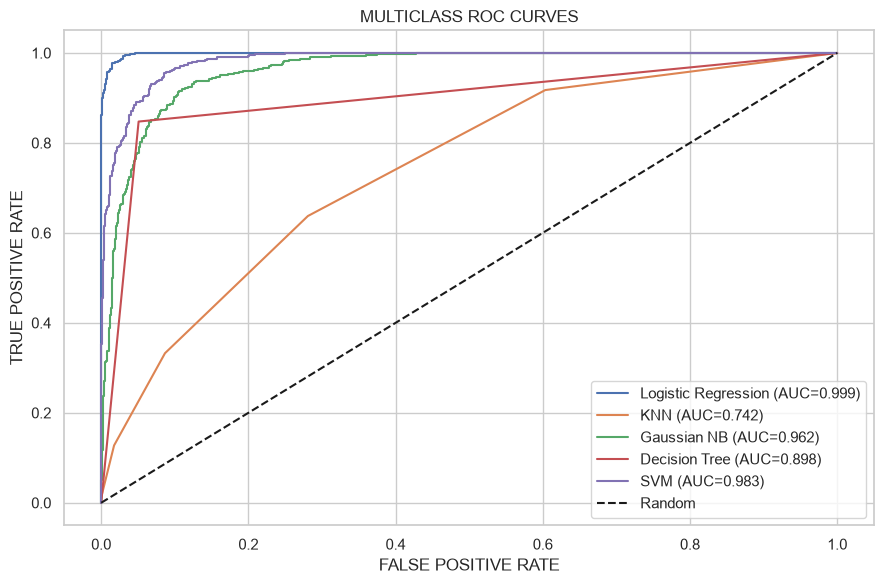

In [71]:
# MODEL COMPARISON
models = {
    "Logistic Regression": (lr_pred, lr_proba),
    "KNN": (knn_pred, knn_proba),
    "Gaussian NB": (nb_pred, nb_proba),
    "Decision Tree": (dt_pred, dt_proba),
    "SVM": (svc_pred, svc_proba)
}

results = []
for name, (pred, proba) in models.items():
    results.append([name, accuracy_score(y_test, pred), precision_score(y_test, pred, average="weighted"), recall_score(y_test, pred, average="weighted"), f1_score(y_test, pred, average="weighted"), roc_auc_score(y_test, proba, multi_class="ovr", average="weighted")])
results_df = pd.DataFrame(results, columns=["Algorithm", "Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"])

print("MODEL PERFORMANCE")
display(results_df.style.format("{:.4f}", subset=results_df.columns[1:]))

# CONFUSION MATRICES
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.ravel()
for i, (name, (pred, _)) in enumerate(models.items()):
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt="d", cmap="Blues", ax=axes[i])
    axes[i].set_title(name)
    axes[i].set_xlabel("PREDICTED")
    axes[i].set_ylabel("ACTUAL")

axes[-1].axis("off")
plt.tight_layout()
plt.show()

# ROC CURVES
y_test_bin = label_binarize(y_test, classes=sorted(y.unique()))
plt.figure(figsize=(9,6))
for name, (_, proba) in models.items():
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), proba.ravel())
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")

plt.plot([0,1], [0,1], "k--", label="Random")
plt.xlabel("FALSE POSITIVE RATE")
plt.ylabel("TRUE POSITIVE RATE")
plt.title("MULTICLASS ROC CURVES")
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
# CROSS VALIDATION
top_two = results_df.sort_values("F1 Score", ascending=False).head(2)["Algorithm"].tolist()
model_map = {
    "Logistic Regression": (lr_model, X_train_lr, X_test_lr),
    "KNN": (knn_model, X_train_knn, X_test_knn),
    "Gaussian NB": (nb_model, X_train_nb, X_test_nb),
    "Decision Tree": (dt_model, X_train_dt, X_test_dt),
    "SVM": (svc_model, X_train_svc, X_test_svc)
}
cv_results = []

for name in top_two:
    model, data, _ = model_map[name]
    scores = cross_val_score(model, data, y_train, cv=5, scoring="f1_weighted")
    cv_results.append([name, scores.mean(), scores.std()])
cv_df = pd.DataFrame(cv_results, columns=["Algorithm", "CV Mean F1", "CV Std"])
print("5-FOLD CROSS VALIDATION")
display(cv_df.style.format("{:.4f}", subset=["CV Mean F1", "CV Std"]))

# HYPERPARAMETER TUNING
grids = {
    "Logistic Regression": (lr_model, X_train_lr, {"model__C": [.01, .1, 1, 10, 100]}),
    "KNN": (knn_model, X_train_knn, {"model__n_neighbors": [3, 5, 7, 9, 11], "model__weights": ["uniform", "distance"], "model__metric": ["euclidean", "manhattan"]})
}

tuned_results = []
for name in ["Logistic Regression", "KNN"]:
    model, data, params = grids[name]
    grid = GridSearchCV(model, params, cv=5, scoring="f1_weighted")
    grid.fit(data, y_train)
    pred = grid.best_estimator_.predict(X_test_lr if name == "Logistic Regression" else X_test_knn)
    proba = grid.best_estimator_.predict_proba(X_test_lr if name == "Logistic Regression" else X_test_knn)
    tuned_results.append([name, grid.best_params_, grid.best_score_, accuracy_score(y_test, pred), f1_score(y_test, pred, average="weighted"), roc_auc_score(y_test, proba, multi_class="ovr", average="weighted")])

tuned_df = pd.DataFrame(tuned_results, columns=["Algorithm", "Best Parameters", "CV F1", "Test Accuracy", "Test F1", "Test ROC AUC"])
print("TUNED MODEL RESULTS")
display(tuned_df.style.format({"CV F1": "{:.4f}", "Test Accuracy": "{:.4f}", "Test F1": "{:.4f}", "Test ROC AUC": "{:.4f}"}))


# SAVE RESULTS
results_df.to_csv("classification_part_A_results.csv", index=False)
cv_df.to_csv("classification_cv_results.csv", index=False)
tuned_df.to_csv("classification_tuned_results.csv", index=False)
print("RESULTS SAVED")

5-FOLD CROSS VALIDATION


,Algorithm,CV Mean F1,CV Std
0,Logistic Regression,0.9475,0.0103
1,SVM,0.8486,0.0181


TUNED MODEL RESULTS


,Algorithm,Best Parameters,CV F1,Test Accuracy,Test F1,Test ROC AUC
0,Logistic Regression,{'model__C': 100},0.9619,0.9800,0.9800,0.9992
1,KNN,"{'model__metric': 'manhattan', 'model__n_neighbors': 11, 'model__weights': 'distance'}",0.5436,0.5900,0.5927,0.8090


RESULTS SAVED
